FINAL PROJECT ML 

In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore") 
sns.set_style("darkgrid", {"grid.color": ".6", 
						"grid.linestyle": ":"})

from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline 
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error 
from sklearn.model_selection import GridSearchCV


In [4]:
dataset = pd.read_csv(r"C:\Users\Bhara\Downloads\gold_price_data.csv",
					parse_dates=["Date"])


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [6]:
dataset.isna().sum().sort_values(ascending=False)

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

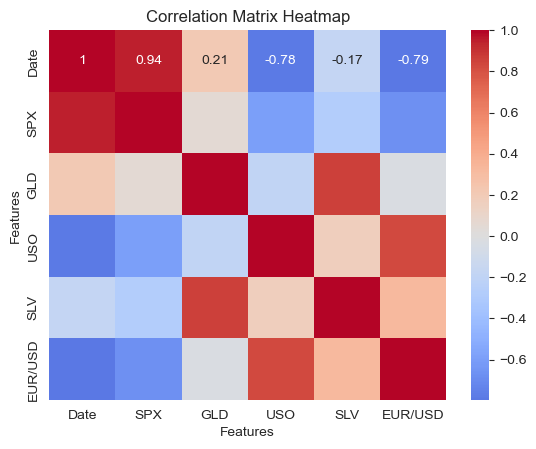

In [7]:

correlation = dataset.corr()


sns.heatmap(correlation, cmap='coolwarm',
			center=0, annot=True)


plt.title('Correlation Matrix Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')


plt.show()


In [8]:

dataset.drop("SLV", axis=1,
			inplace=True)


In [9]:

dataset.set_index("Date", inplace=True)


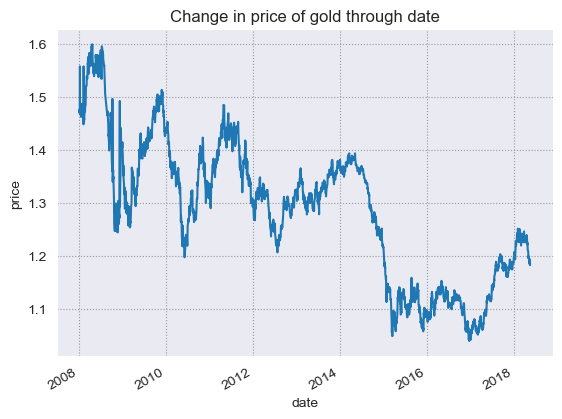

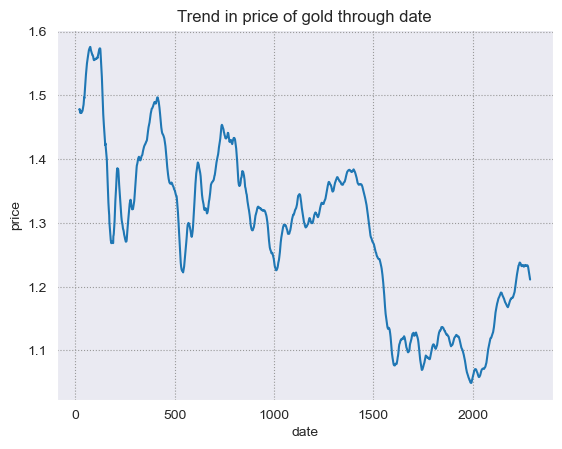

In [11]:
# apply rolling mean with window size of 3
dataset["price_trend"] = dataset["EUR/USD"]\
	.rolling(window=20).mean()

# reset the index to date column
dataset.reset_index("Date", inplace=True)

# since we have used rolling method
# for 20 rows first 2 rows will be NAN
dataset["price_trend"].loc[20:].plot()

# set title of the chart
plt.title("Trend in price of gold through date")

# set x_label of the plot
plt.xlabel("date")
plt.ylabel("price")
plt.show()


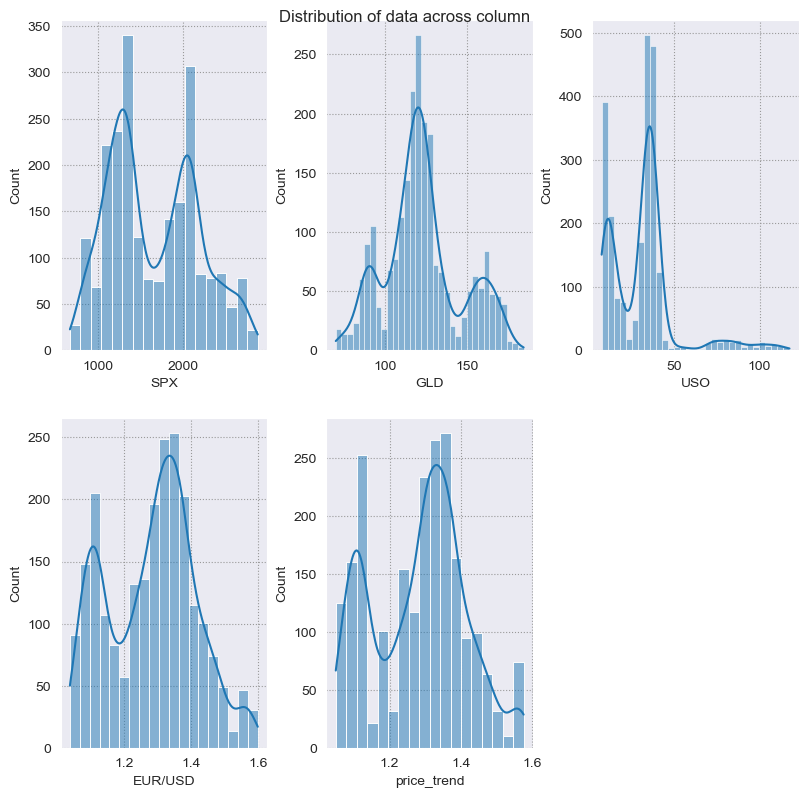

In [12]:
fig = plt.figure(figsize=(8, 8))

# suptitle of the graph
fig.suptitle('Distribution of data across column')
temp = dataset.drop("Date", axis=1).columns.tolist()
for i, item in enumerate(temp):
	plt.subplot(2, 3, i+1)
	sns.histplot(data=dataset, x=item, kde=True)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()


In [48]:
# Exclude the "Date" column from the dataset
numerical_dataset = dataset.drop("Date", axis=1)

# Calculate skewness along the index axis
skewness = numerical_dataset.skew(axis=0, skipna=True)

# Print the skewness of each numerical feature
print(skewness)




SPX            0.263937
GLD            0.375042
USO            0.981611
EUR/USD       -0.170009
price_trend   -0.029588
dtype: float64


In [ ]:
dataset["USO"] = dataset["USO"]\
	.apply(lambda x: np.sqrt(x))


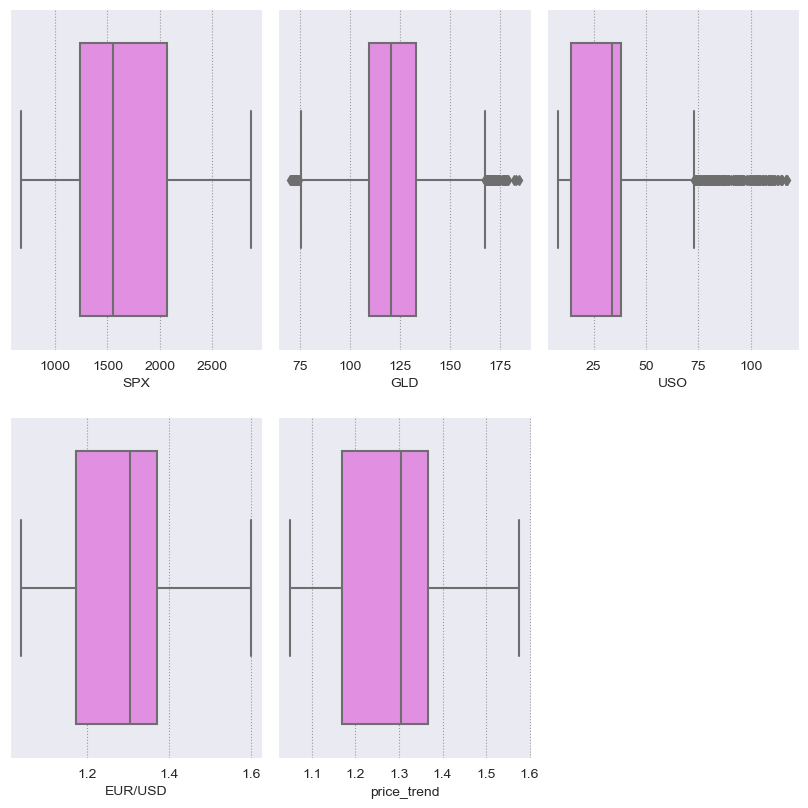

In [14]:
fig = plt.figure(figsize=(8, 8))
temp = dataset.drop("Date", axis=1).columns.tolist()
for i, item in enumerate(temp):
	plt.subplot(2, 3, i+1)
	sns.boxplot(data=dataset, x=item, color='violet')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()


In [15]:
def outlier_removal(column):
	# Capping the outlier rows with Percentiles
	upper_limit = column.quantile(.95)
	# set upper limit to 95percentile
	lower_limit = column.quantile(.05)
	# set lower limit to 5 percentile
	column.loc[(column > upper_limit)] = upper_limit
	column.loc[(column < lower_limit)] = lower_limit
	return column


In [16]:
# Normalize outliers in columns except Date

dataset[['SPX', 'GLD', 'USO', 'EUR/USD']] = \
	dataset[['SPX', 'GLD', 'USO', 'EUR/USD']].apply(outlier_removal)


In [17]:
# select the features and target variable
X = dataset.drop(['Date', 'EUR/USD'], axis=1)

y = dataset['EUR/USD']
# dividing dataset in to train test
x_train, x_test,\
	y_train, y_test = train_test_split(X, y,
									test_size=0.2)


In [18]:
# Create an instance of the StandardScaler
scaler = StandardScaler()

# Fit the StandardScaler on the training dataset
scaler.fit(x_train)

# Transform the training dataset
# using the StandardScaler
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [31]:
from sklearn.impute import SimpleImputer

# Create an imputer object
imputer = SimpleImputer(strategy='mean')

# Impute NaN values in x_train_scaled
x_train_imputed = imputer.fit_transform(x_train_scaled)


In [32]:
poly = PolynomialFeatures(degree=2)

In [33]:
lasso = Lasso()

In [34]:
param_grid = {'lasso__alpha': [1e-4, 1e-3, 1e-2,
							1e-1, 1, 5, 10, 
							20, 30, 40]}

In [35]:
pipeline = make_pipeline(poly, lasso)

In [36]:
lasso_grid_search = GridSearchCV(pipeline,
								param_grid, 
								scoring='r2', cv=3)


In [40]:
import numpy as np

# Check for NaN values in input data
nan_count = np.isnan(x_train_scaled).sum()
print("NaN values in x_train_scaled:", nan_count)



NaN values in x_train_scaled: 16


In [41]:
from sklearn.impute import SimpleImputer

# Define the imputer to replace NaN values with the mean
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform it
x_train_imputed = imputer.fit_transform(x_train_scaled)


In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

# Define a PolynomialFeatures object of degree 2
poly = PolynomialFeatures(degree=2)

# Define a Lasso object
lasso = Lasso()

# Define an Imputer to handle NaN values
imputer = SimpleImputer(strategy='mean')

# Define a pipeline with preprocessing steps including the imputer
pipeline = make_pipeline(imputer, poly, lasso)

# Define a dictionary of parameter values to search over
param_grid = {'lasso__alpha': [1e-4, 1e-3, 1e-2,
                                1e-1, 1, 5, 10, 
                                20, 30, 40]}

# Create a GridSearchCV object with the pipeline and parameter grid
lasso_grid_search = GridSearchCV(pipeline,
                                param_grid, 
                                scoring='r2', cv=3)

# Fit the GridSearchCV object to the imputed training data
lasso_grid_search.fit(x_train_imputed, y_train)

# Predict the target variable using the fitted model and the imputed training data
y_pred = lasso_grid_search.predict(x_train_imputed)

# Compute the R-squared of the fitted model on the imputed train data
r2 = r2_score(y_train, y_pred)

# Print the R-squared
print("R-squared: ", r2)

# Print the best parameter values and score
print('Best parameter values: ',
    lasso_grid_search.best_params_)
print('Best score: ',
    lasso_grid_search.best_score_)


R-squared:  0.966790593202357
Best parameter values:  {'lasso__alpha': 0.0001}
Best score:  0.9652486064621334


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

# Check for NaN values in input data
print("NaN values in x_train_scaled:", np.isnan(x_train_scaled).sum())

# Impute NaN values
imputer = SimpleImputer(strategy='mean')
x_train_imputed = imputer.fit_transform(x_train_scaled)

# Define parameter grid for which to search
param_grid = {'n_estimators': [50, 80, 100],
              'max_depth': [3, 5, 7]}

# Create instance of the RandomForestRegressor
rf = RandomForestRegressor()

# Define GridSearchCV with RandomForestRegressor, parameter grid, scoring, and cross-validation
rf_grid_search = GridSearchCV(rf, param_grid, scoring='r2', cv=2)

# Fit the GridSearchCV object to the imputed training data
rf_grid_search.fit(x_train_imputed, y_train)

# Print the best parameter values and score
print('Best parameter values: ', rf_grid_search.best_params_)
print('Best score: ', rf_grid_search.best_score_)


NaN values in x_train_scaled: 16
Best parameter values:  {'max_depth': 7, 'n_estimators': 100}
Best score:  0.9763234249307253


In [45]:
from sklearn.metrics import r2_score

# Check for NaN values in test data
print("NaN values in x_test_scaled:", np.isnan(x_test_scaled).sum())

# Impute NaN values in test data
x_test_imputed = imputer.transform(x_test_scaled)

# Compute the R-squared of the fitted model on the test data
r2 = r2_score(y_test, rf_grid_search.predict(x_test_imputed))

# Print the R-squared
print("R-squared:", r2)


NaN values in x_test_scaled: 3
R-squared: 0.9794449592373409


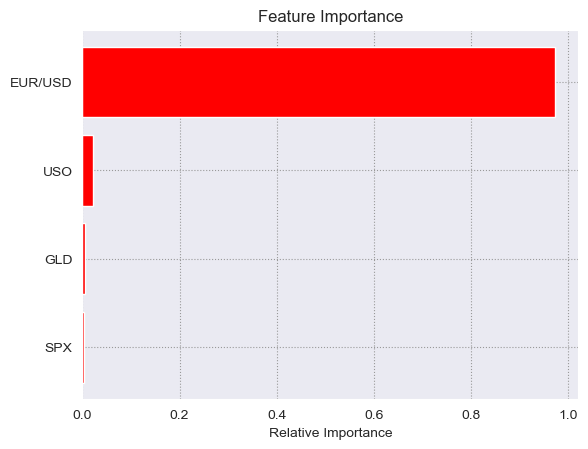

In [46]:
# Access the best estimator from the GridSearchCV object after fitting
best_rf_estimator = rf_grid_search.best_estimator_

# Extract feature importances from the best estimator
importances = best_rf_estimator.feature_importances_

# Access the feature names
features = dataset.drop("Date", axis=1).columns

# Sort feature importances and indices
indices = np.argsort(importances)

# Plot feature importances
plt.title('Feature Importance')
plt.barh(range(len(indices)),
         importances[indices],
         color='red',
         align='center')
plt.yticks(range(len(indices)),
           [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


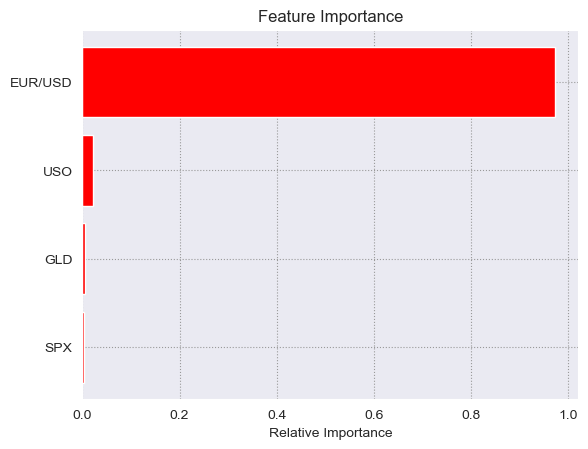

In [47]:
features = dataset.drop("Date", axis=1).columns

# store the importance of the feature
importances = rf_grid_search.best_estimator_.\
	feature_importances_


indices = np.argsort(importances)

# title of the graph
plt.title('Feature Importance')

plt.barh(range(len(indices)),
		importances[indices],
		color='red',
		align='center')

# plot bar chart
plt.yticks(range(len(indices)),
		[features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


In [24]:
# Create an instance of the XGBRegressor model
model_xgb = XGBRegressor()

# Fit the model to the training data
model_xgb.fit(x_train_scaled, y_train)

# Print the R-squared score on the training data
print("Xgboost Accuracy =", r2_score(
	y_train, model_xgb.predict(x_train_scaled)))


Xgboost Accuracy = 0.9994683962491241


In [25]:
# Print the R-squared score on the test data
print("Xgboost Accuracy on test data =",
	r2_score(y_test,
			model_xgb.predict(x_test_scaled)))


Xgboost Accuracy on test data = 0.9887759679766299


In [26]:
pip install eli5

     ---------------------------------------- 0.0/216.2 kB ? eta -:--:--
     --- --------------------------------- 20.5/216.2 kB 640.0 kB/s eta 0:00:01
     ------------ ------------------------ 71.7/216.2 kB 777.7 kB/s eta 0:00:01
     -------------------------------------- 216.2/216.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/47.1 kB ? eta -:--:--
   ---------------------------------------- 47.1/47.1 kB ? eta 0:00:00
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107761 sha256=5d1b5d968251370e3b4993d26dbc4756164ec3c350365d1ec9584e43ea9544bb
  Stored in directory: c:\users\bhara\appdata\local\pip\cache\wheels\ec\68\a9\de7d374ecb6f53462ce0eec8326fbab91b6228c82e67428d0d
Successfully built eli5
Note: you may need to restart the kernel to use updated packages.


In [27]:
import eli5 as eli
# weight of variables in xgboost model
# Get the names of the features
feature_names = x_train.columns.tolist()

# Explain the weights of the features using ELI5
eli.explain_weights(model_xgb,
					feature_names=feature_names)


Weight,Feature
0.9739,price_trend
0.0106,USO
0.0083,GLD
0.0072,SPX


In [28]:
# dump model using pickle library
import pickle

# dump model in file model.pkl
pickle.dump(model_xgb, open('model.pkl', 'wb'))
